In [1]:
import os

base_path = '/kaggle/input/baggage-xray-threats/Augmented_Dataset/GDXray'
image_dir = os.path.join(base_path, 'images')
mask_dir = os.path.join(base_path, 'masks')

print("Image dir exists:", os.path.exists(image_dir))
print("Mask dir exists :", os.path.exists(mask_dir))

print("Sample image files:", os.listdir(image_dir)[:5])
print("Sample mask files :", os.listdir(mask_dir)[:5])


Image dir exists: True
Mask dir exists : True
Sample image files: ['B0049_0157rotated360.jpg', 'B0028_0003rotated360.jpg', 'B0008_0092shifted0_-10.jpg', 'B0049_0191rotated180.jpg', 'B0049_0110rotated180.jpg']
Sample mask files : ['B0049_0035rotated180.png', 'B0046_0073rotated270.png', 'B0050_0091scaled0.8.png', 'B0049_0091scaled0.8.png', 'B0008_0151rotated180.png']


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [3]:
image_paths = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith('.jpg')])
mask_paths  = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])

print("Total images:", len(image_paths))
print("Total masks :", len(mask_paths))

if image_paths and mask_paths:
    print("Example image path:", image_paths[0])
    print("Example mask path :", mask_paths[0])
else:
    print(" No images or masks found. Check the folder paths and file extensions.")


Total images: 11032
Total masks : 11032
Example image path: /kaggle/input/baggage-xray-threats/Augmented_Dataset/GDXray/images/B0001_0001flip-1.jpg
Example mask path : /kaggle/input/baggage-xray-threats/Augmented_Dataset/GDXray/masks/B0001_0001flip-1.png


In [4]:
IMG_SIZE = 256

class XrayDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))  
        mask = (mask > 0).astype(np.float32)  

        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [5]:
train_imgs, temp_imgs, train_masks, temp_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.3,
    random_state=42
)

val_imgs, test_imgs, val_masks, test_masks = train_test_split(
    temp_imgs,
    temp_masks,
    test_size=0.5,
    random_state=42
)

train_dataset = XrayDataset(train_imgs, train_masks)
val_dataset = XrayDataset(val_imgs, val_masks)
test_dataset = XrayDataset(test_imgs, test_masks)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 7722
Number of validation samples: 1655
Number of test samples: 1655


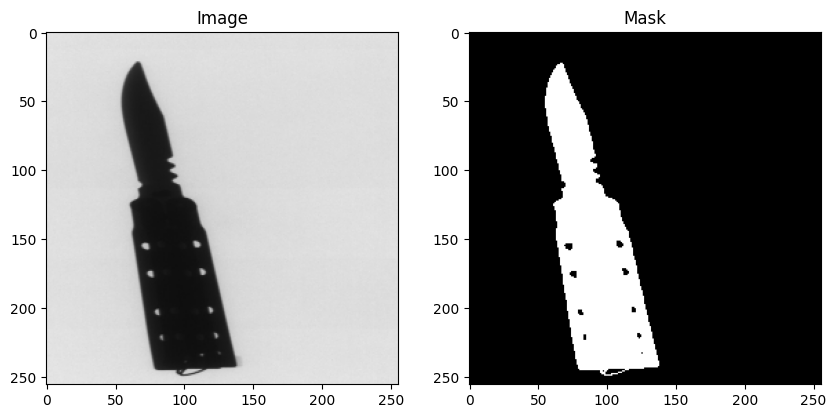

In [6]:
sample_img, sample_mask = train_dataset[0]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.transpose(sample_img.numpy(), (1, 2, 0)))
plt.title("Image")

plt.subplot(1, 2, 2)
plt.imshow(sample_mask.squeeze().numpy(), cmap="gray")
plt.title("Mask")

plt.show()

In [7]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

param_bounds = {
    "lr": (1e-5, 1e-2),
    "batch_size": [4, 8, 16],
    "optimizer": ["adam", "sgd"],
}


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)

In [9]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv1 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv2 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv3 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv4 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))
        d4 = self.down4(self.pool3(d3))
        bn = self.bottleneck(self.pool4(d4))

        up1 = self.up1(bn)
        up1 = self.conv1(torch.cat([up1, d4], dim=1))
        up2 = self.up2(up1)
        up2 = self.conv2(torch.cat([up2, d3], dim=1))
        up3 = self.up3(up2)
        up3 = self.conv3(torch.cat([up3, d2], dim=1))
        up4 = self.up4(up3)
        up4 = self.conv4(torch.cat([up4, d1], dim=1))

        return torch.sigmoid(self.final(up4))

In [10]:
bce_loss = nn.BCELoss()

def dice_loss(pred, target, smooth=1e-6):
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=(2, 3))
    total = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    dice = (2. * intersection + smooth) / (total + smooth)
    return 1 - dice.mean()

def combined_loss(pred, target, weight_bce=0.6, weight_dice=0.4):
    return weight_bce * bce_loss(pred, target) + weight_dice * dice_loss(pred, target)

In [11]:
def build_optimizer(params, model):
    if params["optimizer"] == "adam":
        return torch.optim.Adam(model.parameters(), lr=params["lr"])
    else:
        return torch.optim.SGD(model.parameters(), lr=params["lr"], momentum=0.9)

def fitness(params):
    
    train_loader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=params["batch_size"], shuffle=False, num_workers=2)

    model = UNet().to(device)
    optimizer = build_optimizer(params, model)

    for epoch in range(2):
        model.train()
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = combined_loss(outputs, masks)
            loss.backward()
            optimizer.step()

    model.eval()
    val_dice = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = (outputs > 0.5).float()
            dice = 1 - dice_loss(preds, masks)
            val_dice += dice.item()

    avg_val_dice = val_dice / len(val_loader)
    return 1 - avg_val_dice  

In [12]:
def random_param():
    return {
        "lr": 10 ** random.uniform(np.log10(param_bounds["lr"][0]), np.log10(param_bounds["lr"][1])),
        "batch_size": random.choice(param_bounds["batch_size"]),
        "optimizer": random.choice(param_bounds["optimizer"]),
    }

def hybrid_pso_cuckoo(num_particles=5, max_iter=10):
    particles = [random_param() for _ in range(num_particles)]
    velocities = [0 for _ in range(num_particles)]
    personal_best = particles[:]
    personal_best_scores = [fitness(p) for p in particles]
    global_best = personal_best[np.argmin(personal_best_scores)]

    for t in range(max_iter):
        print(f"--- Iteration {t+1}/{max_iter} ---")
        for i in range(num_particles):
            new_particle = random_param()  
            new_score = fitness(new_particle)

            if new_score < personal_best_scores[i]:
                personal_best[i] = new_particle
                personal_best_scores[i] = new_score

        worst_idx = np.argmax(personal_best_scores)
        new_particle = personal_best[worst_idx].copy()
        new_particle["lr"] *= random.uniform(0.9, 1.1)
        new_particle["lr"] = min(max(new_particle["lr"], param_bounds["lr"][0]), param_bounds["lr"][1])
        personal_best[worst_idx] = new_particle
        personal_best_scores[worst_idx] = fitness(new_particle)

        global_best = personal_best[np.argmin(personal_best_scores)]
        print(f"Best so far: {global_best} with score {min(personal_best_scores):.4f}")

    return global_best

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [14]:
best_hyperparams = hybrid_pso_cuckoo(num_particles=3, max_iter=3)
print("Best Hyperparameters found:", best_hyperparams)


--- Iteration 1/3 ---
Best so far: {'lr': 1.5915529085446136e-05, 'batch_size': 16, 'optimizer': 'adam'} with score 0.0912
--- Iteration 2/3 ---
Best so far: {'lr': 1.5915529085446136e-05, 'batch_size': 16, 'optimizer': 'adam'} with score 0.0912
--- Iteration 3/3 ---
Best so far: {'lr': 1.5915529085446136e-05, 'batch_size': 16, 'optimizer': 'adam'} with score 0.0912
Best Hyperparameters found: {'lr': 1.5915529085446136e-05, 'batch_size': 16, 'optimizer': 'adam'}


In [ ]:
best_lr    = 1.5915529085446136e-05
batch_size = 16
weight_bce = 0.6
weight_dice = 0.4

In [17]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)

In [19]:
bce_loss = nn.BCELoss()

def combined_loss(pred, target):
    return weight_bce * bce_loss(pred, target) + weight_dice * dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)

In [21]:
train_losses = []
val_losses = []
val_dice_scores = []
val_ious = []

best_val_loss = float('inf')
patience = 3
trigger_times = 0
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)

    model.eval()
    val_loss = 0
    val_dice = 0
    iou_scores = []

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = combined_loss(outputs, masks)
            val_loss += loss.item()

            preds = (outputs > 0.5).float()
            dice = 1 - dice_loss(preds, masks)
            val_dice += dice.item()

            masks_bin = (masks > 0.5).float()
            intersection = (preds * masks_bin).sum(dim=(1,2,3))
            union = preds.sum(dim=(1,2,3)) + masks_bin.sum(dim=(1,2,3)) - intersection
            iou_scores.append(((intersection + 1e-6)/(union + 1e-6)).mean().item())

    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)
    avg_val_iou = sum(iou_scores) / len(iou_scores)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_dice_scores.append(avg_val_dice)
    val_ious.append(avg_val_iou)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} - "
          f"Val Loss: {avg_val_loss:.4f} - Val Dice: {avg_val_dice:.4f} - Val IoU: {avg_val_iou:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")
    else:
        trigger_times += 1
        print(f"EarlyStopping trigger times: {trigger_times}/{patience}")
        if trigger_times >= patience:
            print("Early stopping triggered!")
            break

Epoch [1/20] - Train Loss: 0.0416 - Val Loss: 0.0369 - Val Dice: 0.9443 - Val IoU: 0.9166
Epoch [2/20] - Train Loss: 0.0412 - Val Loss: 0.0348 - Val Dice: 0.9465 - Val IoU: 0.9196
Epoch [3/20] - Train Loss: 0.0340 - Val Loss: 0.0311 - Val Dice: 0.9510 - Val IoU: 0.9275
Epoch [4/20] - Train Loss: 0.0324 - Val Loss: 0.0318 - Val Dice: 0.9513 - Val IoU: 0.9252
EarlyStopping trigger times: 1/3
Epoch [5/20] - Train Loss: 0.0306 - Val Loss: 0.0313 - Val Dice: 0.9496 - Val IoU: 0.9269
EarlyStopping trigger times: 2/3
Epoch [6/20] - Train Loss: 0.0253 - Val Loss: 0.0239 - Val Dice: 0.9627 - Val IoU: 0.9419
Epoch [7/20] - Train Loss: 0.0254 - Val Loss: 0.0268 - Val Dice: 0.9602 - Val IoU: 0.9375
EarlyStopping trigger times: 3/3
Early stopping triggered!


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_seg_metrics(preds, labels):
    preds = (preds > 0.5).cpu().numpy().flatten()
    labels = (labels > 0.5).cpu().numpy().flatten()
    # Classification metrics
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds)
    rec = recall_score(labels, preds)
    f1 = f1_score(labels, preds)
    # Segmentation metrics
    intersection = np.logical_and(preds, labels).sum()
    union = np.logical_or(preds, labels).sum()
    iou = intersection / (union + 1e-6)
    dice = 2 * intersection / (preds.sum() + labels.sum() + 1e-6)
    return acc, prec, rec, f1, dice, iou


def evaluate(loader, split_name="Validation"):
    metrics_acc = metrics_prec = metrics_rec = metrics_f1 = 0
    metrics_dice = metrics_iou = 0
    count = 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            acc, prec, rec, f1, dice, iou = compute_seg_metrics(outputs, masks)
            metrics_acc += acc
            metrics_prec += prec
            metrics_rec += rec
            metrics_f1 += f1
            metrics_dice += dice
            metrics_iou += iou
            count += 1
    # average over batches
    print(f"\n{split_name} Metrics:")
    print(f"Accuracy:  {metrics_acc/count:.4f}")
    print(f"Precision: {metrics_prec/count:.4f}")
    print(f"Recall:    {metrics_rec/count:.4f}")
    print(f"F1 Score:  {metrics_f1/count:.4f}")
    print(f"Dice Coef: {metrics_dice/count:.4f}")
    print(f"IoU Score: {metrics_iou/count:.4f}")

# Evaluate on Validation and Test
evaluate(val_loader, "Validation")
evaluate(test_loader, "Test")


Validation Metrics:
Accuracy:  0.9951
Precision: 0.9911
Recall:    0.9788
F1 Score:  0.9849
Dice Coef: 0.9849
IoU Score: 0.9704

Test Metrics:
Accuracy:  0.9950
Precision: 0.9910
Recall:    0.9769
F1 Score:  0.9838
Dice Coef: 0.9838
IoU Score: 0.9684


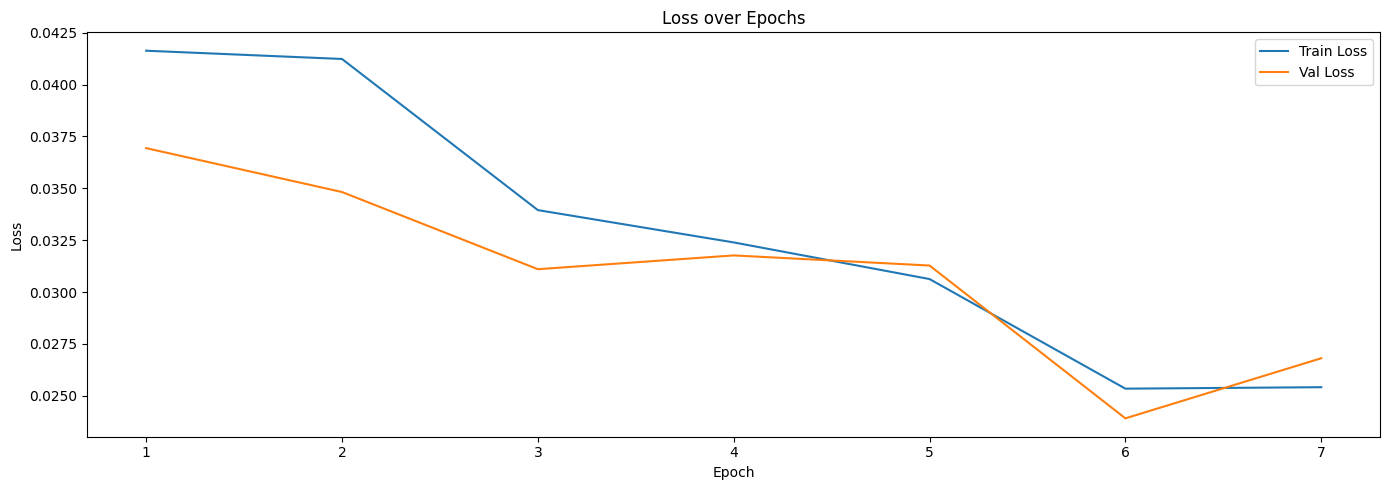

In [23]:
epochs = list(range(1, len(train_losses) + 1))
plt.figure(figsize=(14, 5))
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

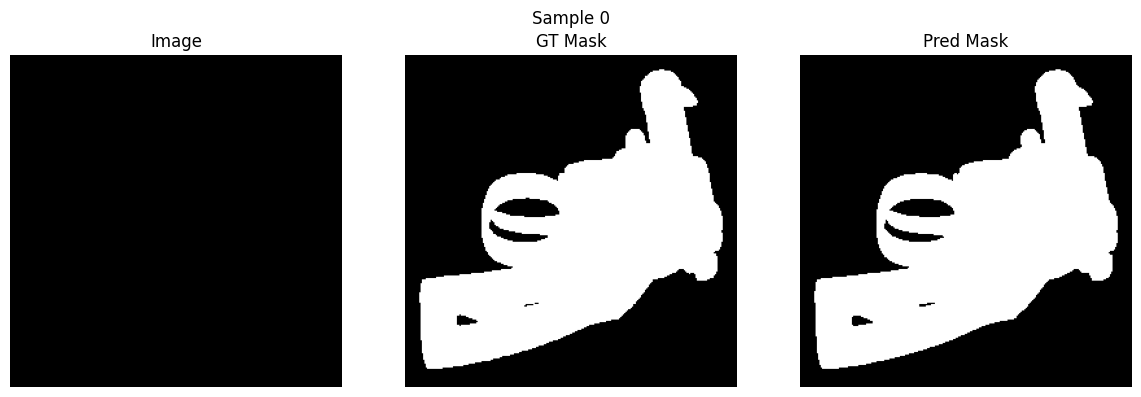

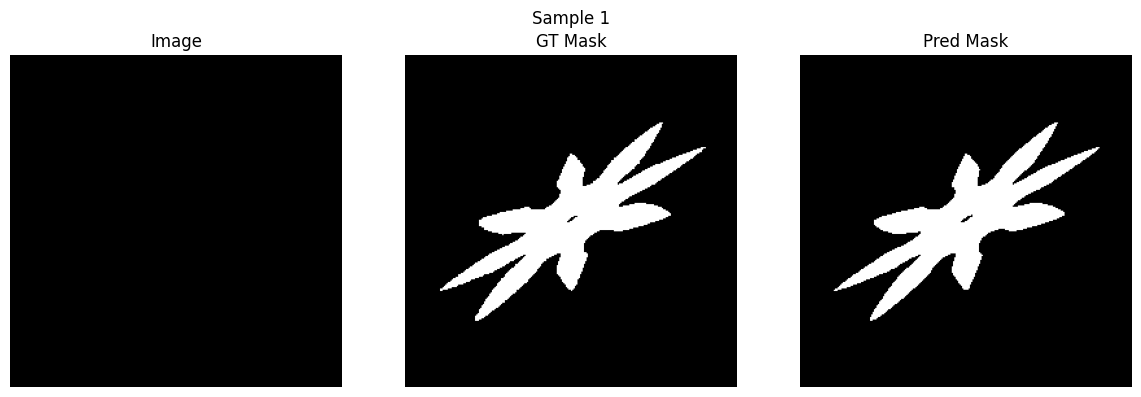

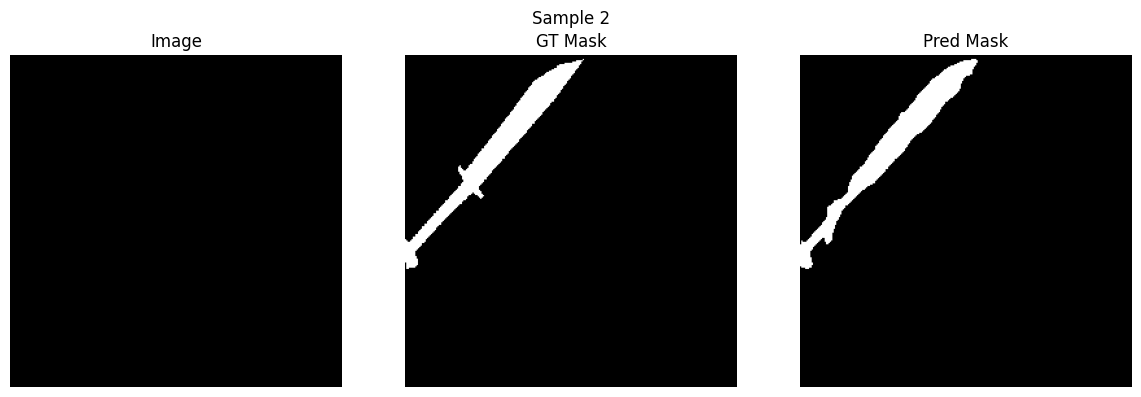

In [24]:
def visualize_prediction(image, mask, pred, idx=None):
    img = image.cpu().numpy().transpose(1, 2, 0)
    mask = mask.cpu().squeeze(0).numpy()
    pred = pred.cpu().squeeze(0).numpy()
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    if idx is not None:
        fig.suptitle(f"Sample {idx}")
    axes[0].imshow(img.astype(np.uint8)); axes[0].set_title("Image"); axes[0].axis('off')
    axes[1].imshow(mask, cmap='gray'); axes[1].set_title("GT Mask"); axes[1].axis('off')
    axes[2].imshow(pred, cmap='gray'); axes[2].set_title("Pred Mask"); axes[2].axis('off')
    plt.tight_layout(); plt.show()

model.eval()
with torch.no_grad():
    for idx, (images, masks) in enumerate(test_loader):
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = (outputs > 0.5).float()
        for i in range(min(3, images.size(0))):
            visualize_prediction(images[i], masks[i], preds[i], idx=i)
        break

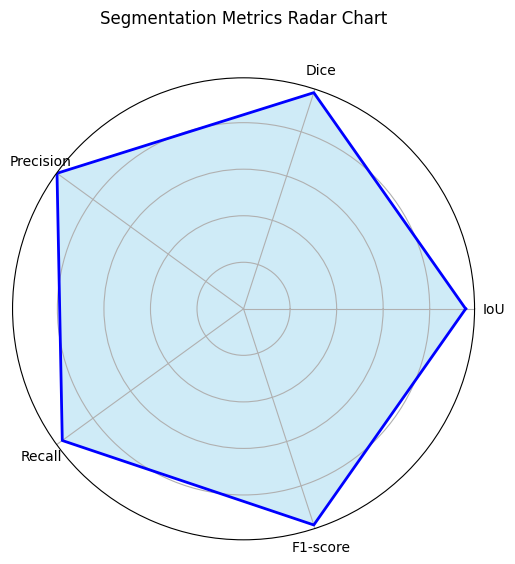

In [25]:
def compute_metrics(preds, labels):
    preds = (preds > 0.5).cpu().numpy().flatten()
    labels = (labels > 0.5).cpu().numpy().flatten()

    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    f1 = f1_score(labels, preds)
    
    intersection = np.logical_and(preds, labels).sum()
    union = np.logical_or(preds, labels).sum()
    iou = intersection / (union + 1e-6)

    dice = 2 * intersection / (preds.sum() + labels.sum() + 1e-6)

    return {'IoU': iou, 'Dice': dice, 'Precision': precision, 'Recall': recall, 'F1-score': f1}

def plot_radar(metrics):
    import matplotlib.pyplot as plt
    import numpy as np

    labels = list(metrics.keys())
    values = list(metrics.values())

    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    values += values[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, color='b', linewidth=2)
    ax.fill(angles, values, color='skyblue', alpha=0.4)
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title("Segmentation Metrics Radar Chart", y=1.1)
    plt.show()


model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)
        outputs = model(images)
        metrics = compute_metrics(outputs, masks)
        plot_radar(metrics)
        break  

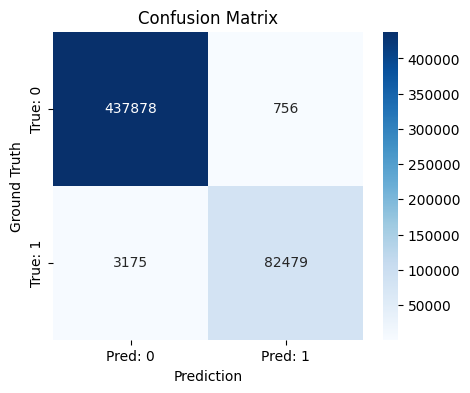

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_heatmap(preds, labels):
    preds = (preds > 0.5).cpu().numpy().flatten()
    labels = (labels > 0.5).cpu().numpy().flatten()

    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: 0', 'Pred: 1'],
                yticklabels=['True: 0', 'True: 1'])
    plt.title("Confusion Matrix")
    plt.xlabel("Prediction")
    plt.ylabel("Ground Truth")
    plt.show()

model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)
        outputs = model(images)

        plot_confusion_heatmap(outputs, masks)
        break

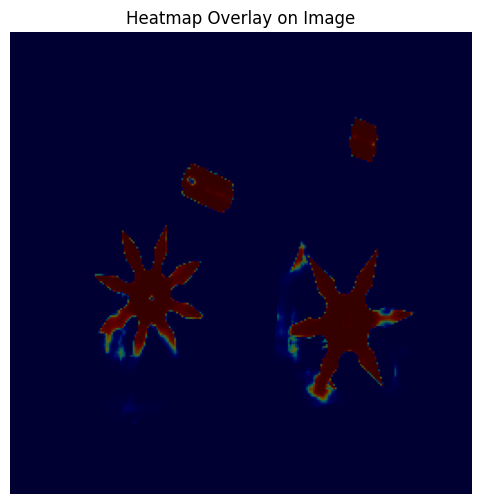

In [27]:
def overlay_heatmap_on_image(image_tensor, pred_tensor):
    import cv2

    img = image_tensor.cpu().numpy().transpose(1, 2, 0).astype(np.uint8)
    pred = pred_tensor.cpu().squeeze(0).numpy()

    heatmap = cv2.applyColorMap((pred * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)
    plt.figure(figsize=(6, 6))
    plt.title("Heatmap Overlay on Image")
    plt.imshow(overlay)
    plt.axis('off')
    plt.show()

model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        outputs = model(images)
        overlay_heatmap_on_image(images[0], outputs[0])
        break


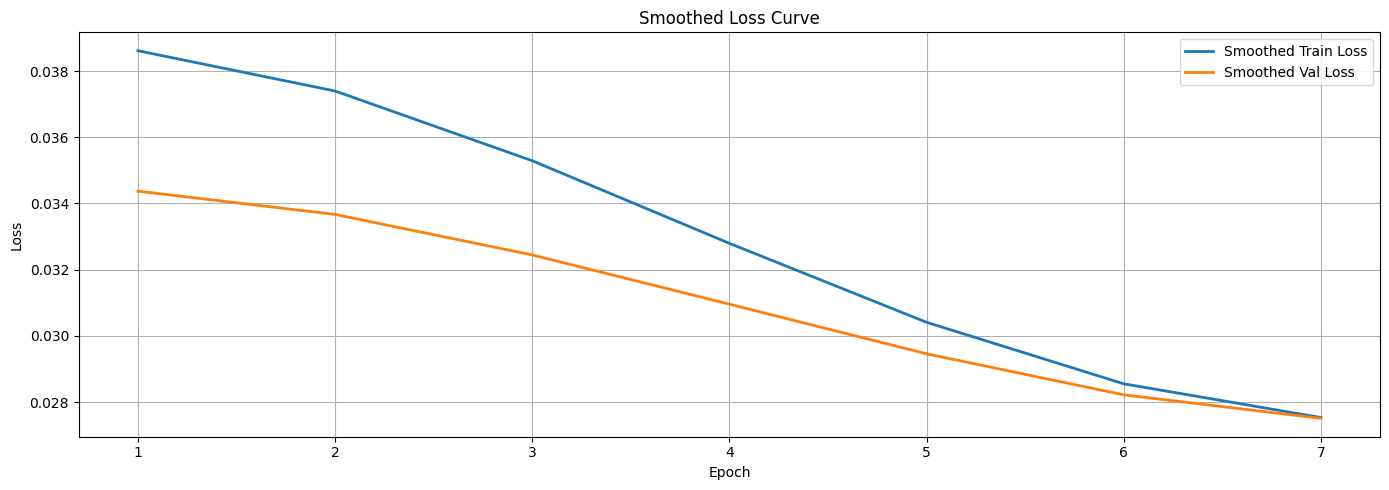

In [28]:
from scipy.ndimage import gaussian_filter1d

smooth_train = gaussian_filter1d(train_losses, sigma=2)
smooth_val = gaussian_filter1d(val_losses, sigma=2)

plt.figure(figsize=(14, 5))
plt.plot(epochs, smooth_train, label='Smoothed Train Loss', linewidth=2)
plt.plot(epochs, smooth_val, label='Smoothed Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Smoothed Loss Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


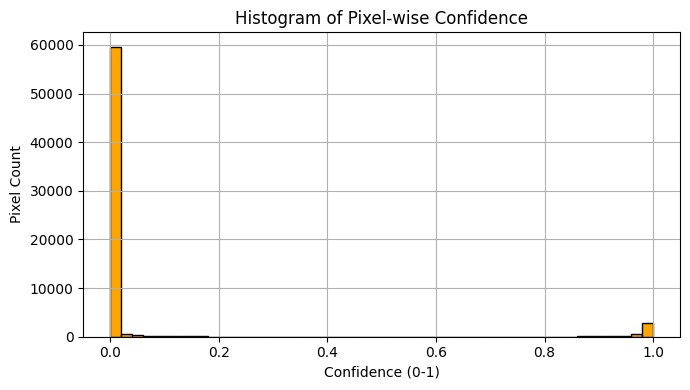

In [29]:
def plot_prediction_confidence_histogram(pred):
    flat_pred = pred.cpu().numpy().flatten()
    plt.figure(figsize=(7, 4))
    plt.hist(flat_pred, bins=50, color='orange', edgecolor='black')
    plt.title("Histogram of Pixel-wise Confidence")
    plt.xlabel("Confidence (0-1)")
    plt.ylabel("Pixel Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

with torch.no_grad():
    for images, _ in val_loader:
        images = images.to(device)
        outputs = model(images)
        plot_prediction_confidence_histogram(outputs[0])
        break


In [35]:
torch.save(model.state_dict(), 'unet_best_model.pth')


In [53]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256, 256)),  
    transforms.ToTensor()
])

In [54]:
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=3, out_channels=1)
model.load_state_dict(torch.load('unet_best_model.pth', map_location=device))
model.to(device)
model.eval()


UNet(
  (down1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=

In [55]:
def predict_image(image_path):
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        output = output.squeeze().cpu().numpy()

    return img, output

In [56]:
test_image_dir = '/kaggle/input/baggage-xray-threats/Augmented_Dataset/GDXray/images'  
test_images = os.listdir(test_image_dir)

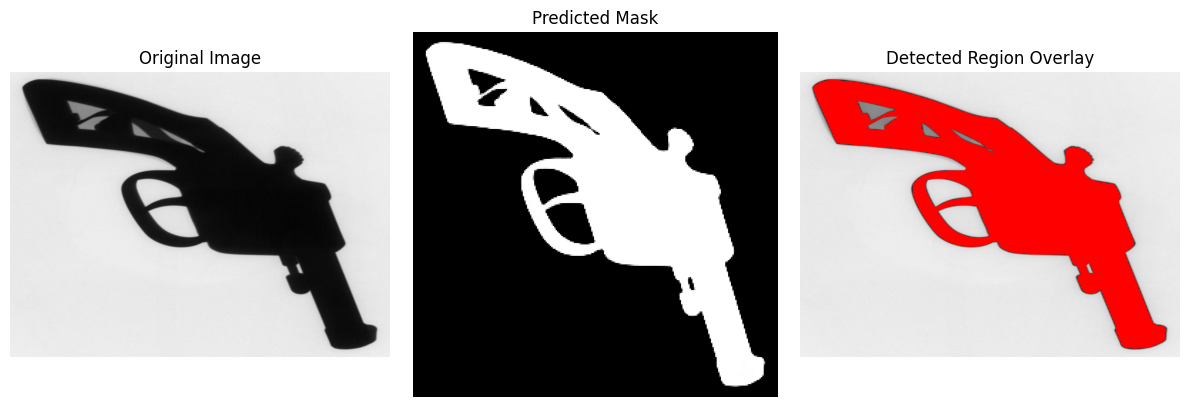

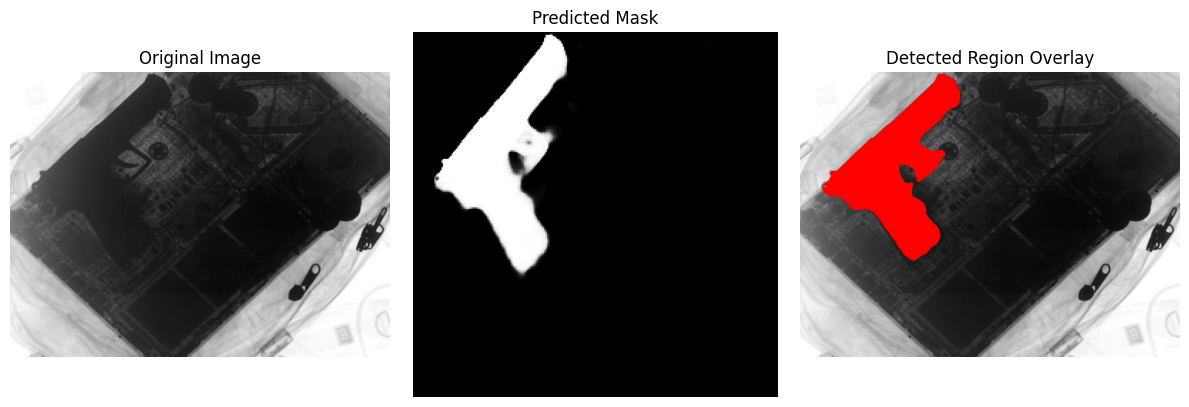

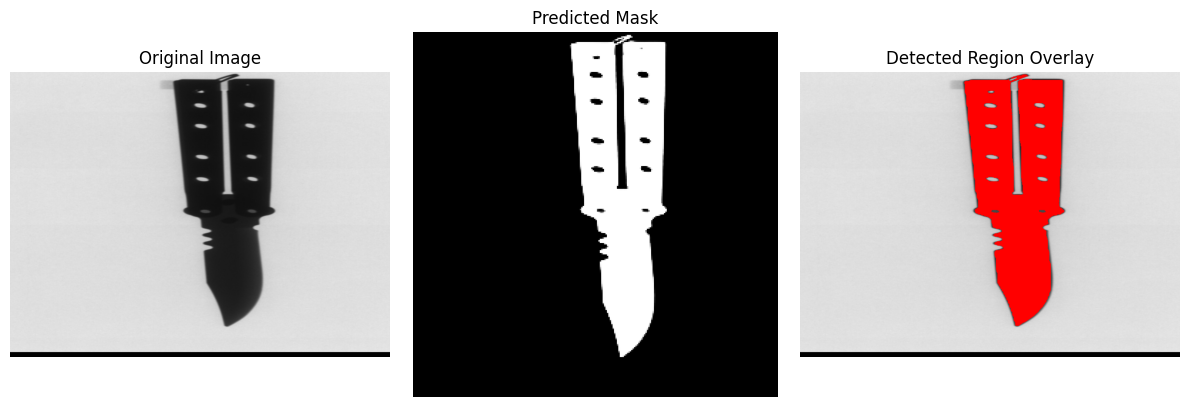

In [58]:
import torchvision.transforms.functional as TF

for i in range(3):  
    image_path = os.path.join(test_image_dir, test_images[i])
    original_img, predicted_mask = predict_image(image_path)

    # Resize predicted mask to match original image size
    original_size = original_img.size  # (width, height)
    mask_img = Image.fromarray((predicted_mask * 255).astype(np.uint8))
    resized_mask = mask_img.resize(original_size, resample=Image.BILINEAR)
    binary_mask = (np.array(resized_mask) > 127).astype(np.uint8)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(original_img)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Predicted Mask")
    plt.imshow(predicted_mask, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Detected Region Overlay")
    overlay = np.array(original_img).copy()
    overlay[binary_mask == 1] = [255, 0, 0]  
    plt.imshow(overlay)
    plt.axis('off')

    plt.tight_layout()
    plt.show()